In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("C:/Users/Administrator/Downloads/E-commerce Customer Behavior - Sheet1.csv")
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [41]:
print(df.shape)
print(df.isnull().sum())
print(df.describe())

(350, 11)
Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64
       Customer ID         Age  Total Spend  Items Purchased  Average Rating  \
count   350.000000  350.000000   350.000000       350.000000      350.000000   
mean    275.500000   33.597143   845.381714        12.600000        4.019143   
std     101.180532    4.870882   362.058695         4.155984        0.580539   
min     101.000000   26.000000   410.800000         7.000000        3.000000   
25%     188.250000   30.000000   502.000000         9.000000        3.500000   
50%     275.500000   32.500000   775.200000        12.000000        4.100000   
75%     362.750000   37.000000  1160.600000        15.000000        4.500000   
max    

In [42]:
rfm = df[['Customer ID', 
          'Days Since Last Purchase', 
          'Items Purchased', 
          'Total Spend']]

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,101,25,14,1120.20
1,102,18,11,780.50
2,103,42,9,510.75
3,104,12,19,1480.30
4,105,55,13,720.40


In [43]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'Monetary']]
)

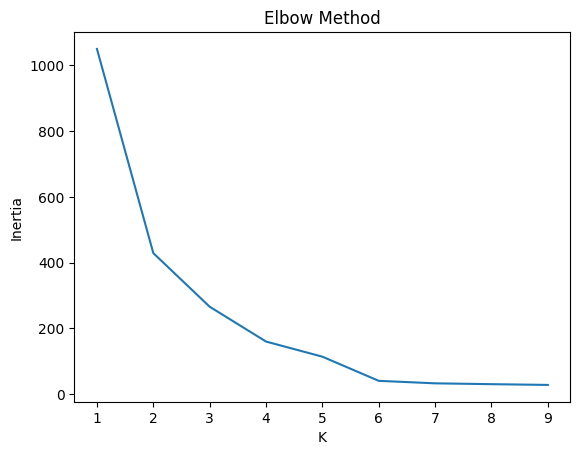

In [44]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia)
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [ ]:
# Create RFM 
rfm = df[['Customer ID', 
          'Days Since Last Purchase', 
          'Items Purchased', 
          'Total Spend']].copy()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

rfm.loc[:, 'Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,101,25,14,1120.20,1
1,102,18,11,780.50,1
2,103,42,9,510.75,0
3,104,12,19,1480.30,2
4,105,55,13,720.40,0


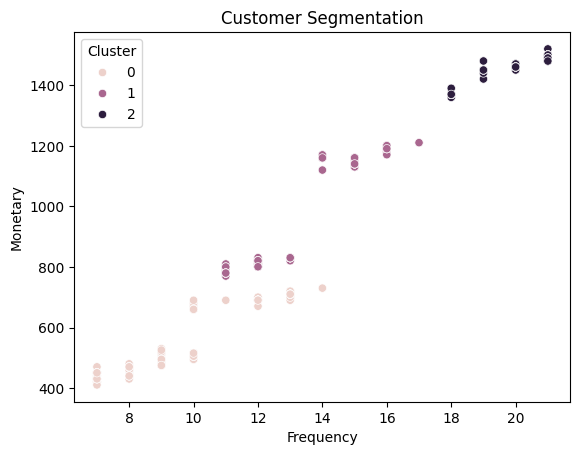

In [46]:
sns.scatterplot(
    x=rfm['Frequency'],
    y=rfm['Monetary'],
    hue=rfm['Cluster']
)

plt.title("Customer Segmentation")
plt.show()

In [47]:
cluster_summary = rfm.groupby('Cluster').mean()
print(cluster_summary)

         CustomerID    Recency  Frequency     Monetary
Cluster                                               
0        276.097701  36.241379   9.540230   545.722414
1        275.076271  19.932203  13.474576   985.263559
2        274.568966  11.172414  20.000000  1459.772414


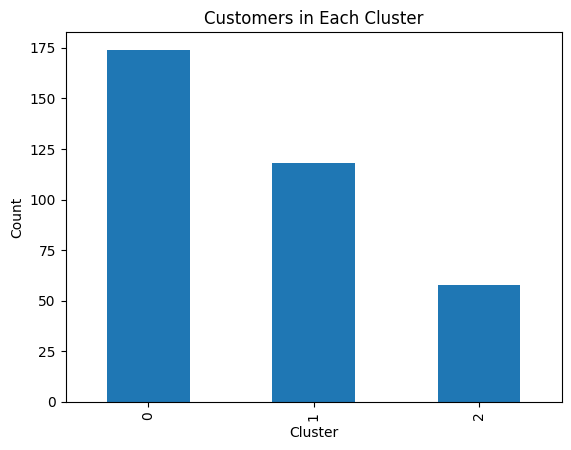

In [48]:
rfm['Cluster'].value_counts().plot(kind='bar')

plt.title("Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

# Insights section:

- Different customer segments require different marketing strategies.
- High-value customers should be retained.
- Medium customers should be nurtured.
- Low-value customers should be re-engaged carefully.